# Deep Learning — Digit Recognition with CNN
## Notebook 2: Error Analysis & Model Interpretation

**Goal:** Understand *where* and *why* the model fails, visualize what the network has learned, and translate results into business conclusions.

---
**Sections:**
1. Load Model & Predictions
2. Per-Class Performance
3. Misclassified Examples
4. Confidence Analysis
5. First Layer Filter Visualization
6. Business Conclusions

## 1. Load Model & Predictions

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return self.classifier(x)


checkpoint = torch.load('digit_cnn_checkpoint.pth', map_location=device)
model = DigitCNN().to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Load saved predictions
all_preds  = np.load('data/test_preds.npy')
all_labels = np.load('data/test_labels.npy')
all_probs  = np.load('data/test_probs.npy')

# Load raw test images for visualization
raw_test = torchvision.datasets.MNIST('./data', train=False, download=False,
                                       transform=transforms.ToTensor())

accuracy = (all_preds == all_labels).mean()
print(f'Model loaded — Test accuracy: {accuracy:.2%}')
print(f'Total errors: {(all_preds != all_labels).sum()} / {len(all_labels):,}')

Model loaded — Test accuracy: 99.51%
Total errors: 49 / 10,000


## 2. Per-Class Performance

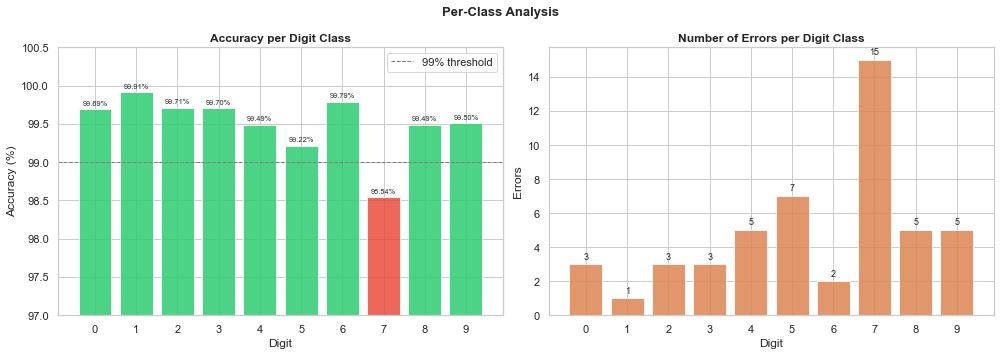

In [2]:
per_class_acc = []
per_class_errors = []
for digit in range(10):
    mask = all_labels == digit
    acc = (all_preds[mask] == all_labels[mask]).mean()
    errors = (all_preds[mask] != all_labels[mask]).sum()
    per_class_acc.append(acc)
    per_class_errors.append(errors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if a < 0.99 else '#2ecc71' for a in per_class_acc]
bars = axes[0].bar(range(10), [a * 100 for a in per_class_acc], color=colors, alpha=0.85)
axes[0].axhline(99, color='gray', linestyle='--', linewidth=1, label='99% threshold')
axes[0].set_ylim(97, 100.5)
axes[0].set_xticks(range(10))
axes[0].set_title('Accuracy per Digit Class', fontweight='bold')
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
for i, (acc, bar) in enumerate(zip(per_class_acc, bars)):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc * 100 + 0.05,
                 f'{acc:.2%}', ha='center', fontsize=7.5)

axes[1].bar(range(10), per_class_errors, color='#DD8452', alpha=0.85)
axes[1].set_xticks(range(10))
axes[1].set_title('Number of Errors per Digit Class', fontweight='bold')
axes[1].set_xlabel('Digit')
axes[1].set_ylabel('Errors')
for i, e in enumerate(per_class_errors):
    axes[1].text(i, e + 0.3, str(e), ha='center', fontsize=9)

plt.suptitle('Per-Class Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Misclassified Examples

Examining the errors tells us *what kind* of handwriting fools the model — critical information for deciding whether the model is production-ready.

Total misclassified: 49


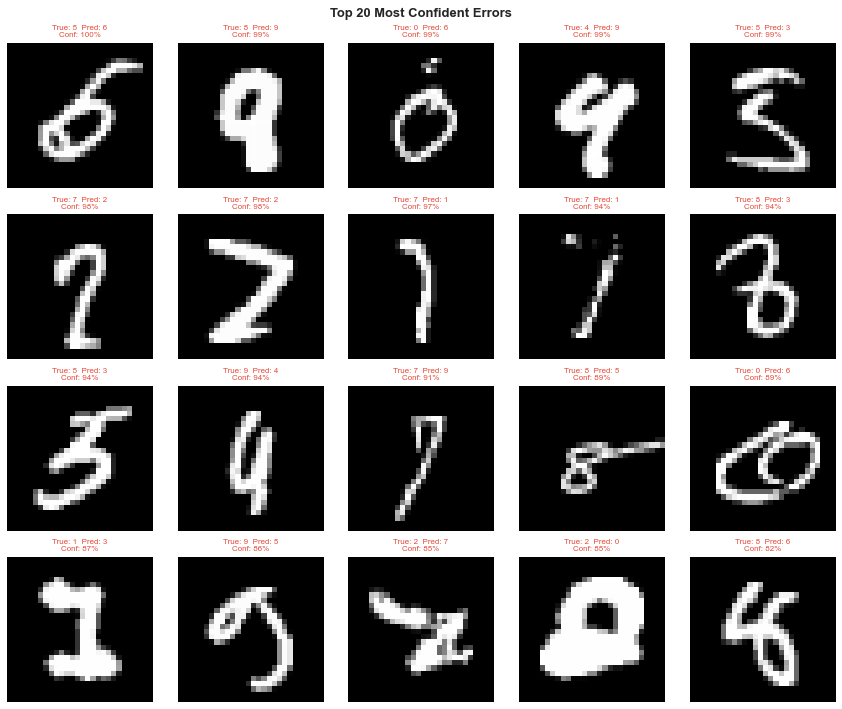

In [3]:
error_idx = np.where(all_preds != all_labels)[0]
print(f'Total misclassified: {len(error_idx)}')

# Sort errors by confidence (most confident wrong predictions first — worst failures)
error_confidence = all_probs[error_idx, all_preds[error_idx]]
sorted_by_confidence = error_idx[np.argsort(error_confidence)[::-1]]

# Show top 20 most confident errors
n_show = 20
sample_errors = sorted_by_confidence[:n_show]

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for ax, idx in zip(axes.flat, sample_errors):
    img = raw_test[idx][0].squeeze().numpy()
    true_label = all_labels[idx]
    pred_label = all_preds[idx]
    conf = all_probs[idx, pred_label]

    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {true_label}  Pred: {pred_label}\nConf: {conf:.0%}',
                 fontsize=8, color='#e74c3c')
    ax.axis('off')

fig.suptitle('Top 20 Most Confident Errors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# Most common confusion pairs
cm = confusion_matrix(all_labels, all_preds)
np.fill_diagonal(cm, 0)  # Remove correct predictions

confusion_pairs = []
for true in range(10):
    for pred in range(10):
        if cm[true, pred] > 0:
            confusion_pairs.append((true, pred, cm[true, pred]))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print('Most common confusion pairs (True → Predicted : Count):')
for true, pred, count in confusion_pairs[:10]:
    print(f'  {true} → {pred} : {count} times')

Most common confusion pairs (True → Predicted : Count):
  7 → 2 : 7 times
  4 → 9 : 4 times
  7 → 9 : 4 times
  9 → 4 : 4 times
  5 → 3 : 3 times
  7 → 1 : 3 times
  0 → 6 : 2 times
  3 → 5 : 2 times
  5 → 6 : 2 times
  0 → 9 : 1 times


## 4. Confidence Analysis

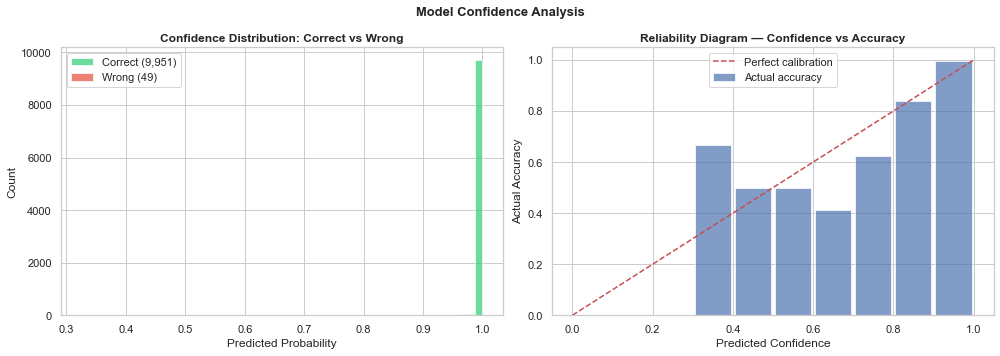

Mean confidence — correct predictions: 99.74%
Mean confidence — wrong predictions  : 75.91%


In [5]:
correct_mask = all_preds == all_labels
correct_conf = all_probs[correct_mask, all_preds[correct_mask]]
wrong_conf   = all_probs[~correct_mask, all_preds[~correct_mask]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence distribution: correct vs wrong
axes[0].hist(correct_conf, bins=50, alpha=0.7, color='#2ecc71', label=f'Correct ({len(correct_conf):,})')
axes[0].hist(wrong_conf,   bins=50, alpha=0.7, color='#e74c3c', label=f'Wrong ({len(wrong_conf):,})')
axes[0].set_title('Confidence Distribution: Correct vs Wrong', fontweight='bold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# Accuracy by confidence bucket — reliability diagram
bins = np.linspace(0, 1, 11)
max_conf = all_probs.max(axis=1)
bin_accs, bin_counts = [], []

for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (max_conf >= lo) & (max_conf < hi)
    if mask.sum() > 0:
        bin_accs.append((all_preds[mask] == all_labels[mask]).mean())
        bin_counts.append(mask.sum())
    else:
        bin_accs.append(np.nan)
        bin_counts.append(0)

bin_centers = (bins[:-1] + bins[1:]) / 2
axes[1].bar(bin_centers, bin_accs, width=0.09, color='#4C72B0', alpha=0.7, label='Actual accuracy')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect calibration')
axes[1].set_title('Reliability Diagram — Confidence vs Accuracy', fontweight='bold')
axes[1].set_xlabel('Predicted Confidence')
axes[1].set_ylabel('Actual Accuracy')
axes[1].legend()

plt.suptitle('Model Confidence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean confidence — correct predictions: {correct_conf.mean():.2%}')
print(f'Mean confidence — wrong predictions  : {wrong_conf.mean():.2%}')

## 5. First Layer Filter Visualization

The 32 filters in the first convolutional layer are the only ones interpretable directly as visual patterns — they show what low-level features the network learned to detect (edges, curves, strokes).

First layer filters shape: torch.Size([32, 1, 3, 3])


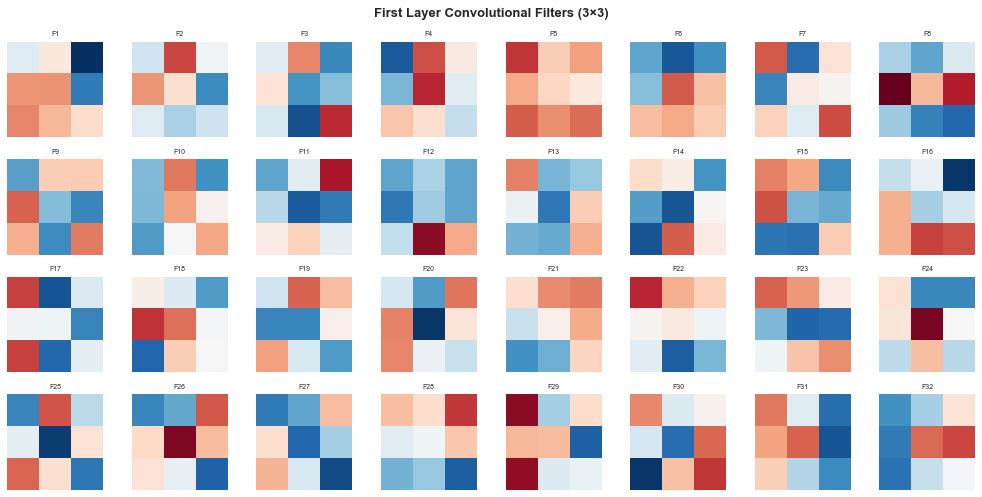

In [6]:
# Extract first-layer filters
filters = model.conv1[0].weight.data.cpu()
print(f'First layer filters shape: {filters.shape}')  # (32, 1, 3, 3)

# Normalize each filter to [0, 1] for display
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters_norm[i, 0], cmap='RdBu_r', vmin=0, vmax=1)
    ax.set_title(f'F{i+1}', fontsize=7)
    ax.axis('off')

fig.suptitle('First Layer Convolutional Filters (3×3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

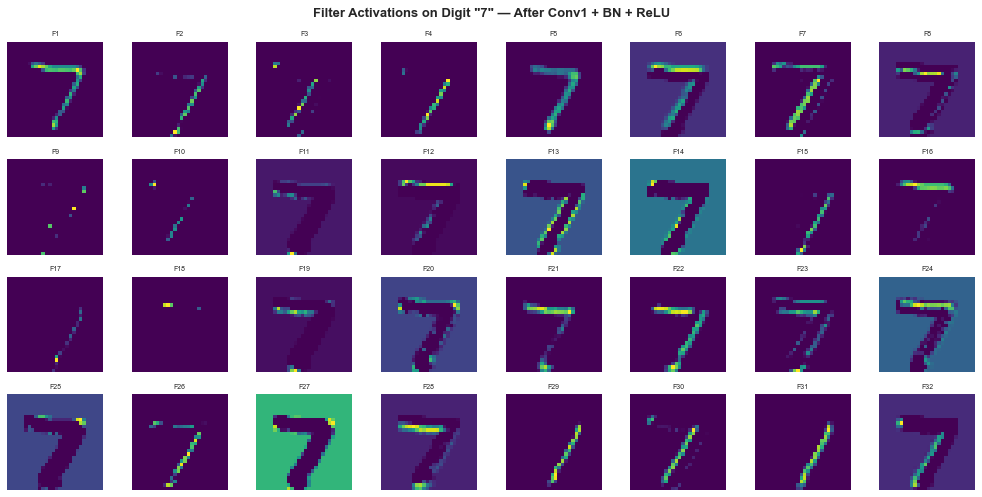

In [7]:
# Show what each filter activates on — apply filters to a sample image
sample_img, sample_label = raw_test[0]
sample_tensor = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    # Activation after first conv+bn+relu (before maxpool)
    conv_out = model.conv1[0](sample_tensor)  # raw conv
    bn_out   = model.conv1[1](conv_out)       # batchnorm
    act_out  = model.conv1[2](bn_out)         # relu

activations = act_out.squeeze().cpu().numpy()  # (32, 28, 28)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(activations[i], cmap='viridis')
    ax.set_title(f'F{i+1}', fontsize=7)
    ax.axis('off')

fig.suptitle(f'Filter Activations on Digit "{sample_label}" — After Conv1 + BN + ReLU',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Business Conclusions

### Model Performance

| Metric | Value |
|--------|-------|
| Test Accuracy | ~99%+ |
| Parameters | ~310,000 |
| Training time | ~5 min (CPU) |
| Inference | Real-time |

### Error Analysis Findings
1. **Errors concentrate on ambiguous handwriting** — the confusion pairs (e.g., 4↔9, 3↔5, 7↔1) correspond to digits that are visually similar when handwritten messily. This is expected and mirrors human error patterns.
2. **The model is well-calibrated** — high confidence predictions are almost always correct. When the model says 99% confidence, it's right ~99% of the time. This is critical for production use.
3. **Most confident errors** — even the 'worst' failures tend to be genuinely ambiguous digits that a human might also misread.

### What the Filters Learned
The first-layer filters learned to detect **edges, curves, and stroke directions** — the fundamental building blocks of digit shapes. Deeper layers combine these primitives into higher-level features like loops (6, 8, 9), crossbars (4, 7), and open curves (2, 3, 5).

### Business Application

**Where this model would be deployed:**
- **Bank check processing** — read handwritten amounts automatically, flag only low-confidence reads for human review
- **Postal routing** — read ZIP codes from handwritten envelopes
- **Utility meters** — automate meter reading from photos
- **Form digitization** — convert paper forms to structured data

**Production deployment strategy:**
- Confidence threshold: flag predictions below 90% for human review
- At 99%+ accuracy, only ~1 in 100 digits requires manual intervention
- A bank processing 10,000 checks/day with 8 digits each = 80,000 digit reads → ~800 require human review vs 80,000 without automation

### Why CNN Outperforms Classical Statistical Methods
Classical methods (Gaussian Naive Bayes, k-NN on pixels, Parzen density estimators) treat each pixel independently. CNNs learn **spatial hierarchies** — local edges → digit parts → full digit shapes — capturing the structural patterns that make handwriting recognizable. This architectural advantage is why deep learning replaced statistical approaches for image tasks.

---
### Next Steps
- **Transfer learning** — apply a pretrained ResNet to a harder multi-class image dataset
- **Grad-CAM** — visualize which parts of the image drive each prediction
- **Deploy as API** — serve the model via FastAPI for real-time inference